In [1]:
# Cell 1: Imports
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from vaderSentiment.vaderSentiment import SentimentIntensityAnalyzer
from scipy.stats import pearsonr
import os
import warnings
warnings.filterwarnings('ignore')

os.chdir('/home/code0053/news-sentiment-analysis')
plt.style.use('seaborn-v0_8')

print("Libraries loaded!")

Libraries loaded!


In [2]:
# Cell 2: Load Data
# Load news
news_df = pd.read_csv('data/raw/raw_analyst_ratings.csv')
news_df['date'] = pd.to_datetime(news_df['date'], format='mixed', utc=True)
news_df['date_only'] = news_df['date'].dt.date

# Load stock data
import glob
stock_files = glob.glob('data/processed/*.csv')
stocks = {}
for f in stock_files:
    ticker = os.path.basename(f).replace('_processed.csv', '')
    df = pd.read_csv(f)
    df['Date'] = pd.to_datetime(df['Date'])
    stocks[ticker] = df
    print(f" {ticker} loaded: {df.shape}")

print(f"\nNews dataset: {news_df.shape}")
print(f"Stocks loaded: {list(stocks.keys())}")

 GOOG loaded: (3774, 14)
 META loaded: (2923, 14)
 NVDA loaded: (3774, 14)
 AMZN loaded: (3774, 14)
 AAPL loaded: (3774, 14)

News dataset: (1407328, 7)
Stocks loaded: ['GOOG', 'META', 'NVDA', 'AMZN', 'AAPL']


In [4]:
# Cell 3: Sentiment Analysis
analyzer = SentimentIntensityAnalyzer()

def get_sentiment(headline):
    score = analyzer.polarity_scores(str(headline))
    return score['compound']

# Apply sentiment to all headlines
print("Running sentiment analysis on 1.4M headlines... (may take a few minutes)")
news_df['sentiment_score'] = news_df['headline'].apply(get_sentiment)

print("Done!")
print("\n=== Sentiment Score Stats ===")
print(news_df['sentiment_score'].describe())

# Classify sentiment
def classify_sentiment(score):
    if score >= 0.05:
        return 'positive'
    elif score <= -0.05:
        return 'negative'
    else:
        return 'neutral'

news_df['sentiment_label'] = news_df['sentiment_score'].apply(classify_sentiment)
print("\n=== Sentiment Distribution ===")
print(news_df['sentiment_label'].value_counts())

Running sentiment analysis on 1.4M headlines... (may take a few minutes)
Done!

=== Sentiment Score Stats ===
count    1.407328e+06
mean     6.690980e-02
std      2.722861e-01
min     -9.578000e-01
25%      0.000000e+00
50%      0.000000e+00
75%      2.023000e-01
max      9.741000e-01
Name: sentiment_score, dtype: float64

=== Sentiment Distribution ===
sentiment_label
neutral     739332
positive    442936
negative    225060
Name: count, dtype: int64


In [5]:
# Cell 4: Date Alignment - Match news to trading days
# Filter news to only stocks we have price data for
target_stocks = list(stocks.keys())
print(f"Target stocks: {target_stocks}")

news_filtered = news_df[news_df['stock'].isin(target_stocks)].copy()
print(f"Filtered news shape: {news_filtered.shape}")

# Aggregate daily sentiment per stock
daily_sentiment = news_filtered.groupby(['date_only', 'stock']).agg(
    avg_sentiment=('sentiment_score', 'mean'),
    article_count=('headline', 'count')
).reset_index()

daily_sentiment['date_only'] = pd.to_datetime(daily_sentiment['date_only'])
print(f"\nDaily sentiment shape: {daily_sentiment.shape}")
print(daily_sentiment.head(10))

Target stocks: ['GOOG', 'META', 'NVDA', 'AMZN', 'AAPL']
Filtered news shape: (5064, 9)

Daily sentiment shape: (1691, 4)
   date_only stock  avg_sentiment  article_count
0 2011-03-03  NVDA      -0.571900              1
1 2011-03-07  NVDA      -0.290300              2
2 2011-03-08  NVDA       0.023400              4
3 2011-03-09  NVDA       0.000000              3
4 2011-03-10  NVDA       0.202300              2
5 2011-03-15  NVDA      -0.049567              3
6 2011-03-16  NVDA      -0.098667              3
7 2011-03-22  NVDA       0.202300              1
8 2011-03-24  NVDA       0.134867              3
9 2011-03-28  NVDA       0.175150              4


In [6]:
# Cell 5: Calculate Daily Returns for each stock
all_returns = []

for ticker, df in stocks.items():
    df = df.copy()
    df['Daily_Return'] = df['Close'].pct_change() * 100
    df['stock'] = ticker
    df = df[['Date', 'stock', 'Daily_Return', 'Close']].dropna()
    all_returns.append(df)

returns_df = pd.concat(all_returns, ignore_index=True)
returns_df.columns = ['date_only', 'stock', 'Daily_Return', 'Close']
returns_df['date_only'] = pd.to_datetime(returns_df['date_only'])

print(f"Returns shape: {returns_df.shape}")
print(returns_df.head())

Returns shape: (18014, 4)
   date_only stock  Daily_Return     Close
0 2009-01-05  GOOG      2.094467  8.115089
1 2009-01-06  GOOG      1.832057  8.263762
2 2009-01-07  GOOG     -3.607137  7.965677
3 2009-01-08  GOOG      0.987523  8.044340
4 2009-01-09  GOOG     -3.112007  7.794000


In [7]:
# Cell 6: Merge sentiment with returns
merged_df = pd.merge(daily_sentiment, returns_df, on=['date_only', 'stock'], how='inner')

print(f"Merged shape: {merged_df.shape}")
print(f"\nSample:\n{merged_df.head()}")
print(f"\nNull values:\n{merged_df.isnull().sum()}")

Merged shape: (1566, 6)

Sample:
   date_only stock  avg_sentiment  article_count  Daily_Return     Close
0 2011-03-03  NVDA        -0.5719              1      0.578321  0.478385
1 2011-03-07  NVDA        -0.2903              2     -1.396890  0.469216
2 2011-03-08  NVDA         0.0234              4     -4.494412  0.448128
3 2011-03-09  NVDA         0.0000              3     -2.097166  0.438730
4 2011-03-10  NVDA         0.2023              2     -6.374086  0.410765

Null values:
date_only        0
stock            0
avg_sentiment    0
article_count    0
Daily_Return     0
Close            0
dtype: int64


In [8]:
# Cell 7: Pearson Correlation Analysis
from scipy.stats import pearsonr

print("=== Pearson Correlation: Sentiment vs Daily Returns ===\n")

# Overall correlation
corr, pvalue = pearsonr(merged_df['avg_sentiment'], merged_df['Daily_Return'])
print(f"Overall Correlation : {corr:.4f}")
print(f"P-value             : {pvalue:.4f}")
print(f"Significant         : {'Yes' if pvalue < 0.05 else 'No'}")

# Per stock correlation
print("\n=== Per Stock Correlation ===")
for ticker in merged_df['stock'].unique():
    df_stock = merged_df[merged_df['stock'] == ticker]
    corr, pvalue = pearsonr(df_stock['avg_sentiment'], df_stock['Daily_Return'])
    print(f"{ticker}: r={corr:.4f}, p={pvalue:.4f}, significant={'Yes' if pvalue < 0.05 else 'No'}")

=== Pearson Correlation: Sentiment vs Daily Returns ===

Overall Correlation : 0.2050
P-value             : 0.0000
Significant         : Yes

=== Per Stock Correlation ===
NVDA: r=0.2148, p=0.0000, significant=Yes
GOOG: r=0.1895, p=0.0003, significant=Yes
AAPL: r=0.1239, p=0.3413, significant=No
AMZN: r=0.1668, p=0.3963, significant=No


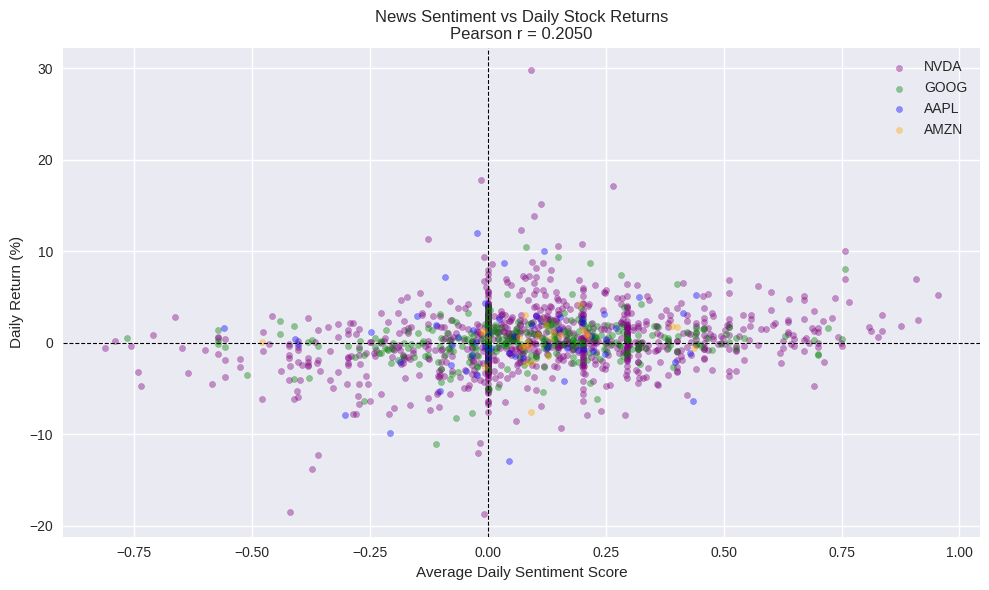

Scatter plot saved!


In [9]:
# Cell 8: Scatter Plot - Sentiment vs Daily Returns
plt.figure(figsize=(10, 6))
colors = {'AAPL': 'blue', 'AMZN': 'orange', 'GOOG': 'green', 'META': 'red', 'NVDA': 'purple'}

for ticker in merged_df['stock'].unique():
    df_stock = merged_df[merged_df['stock'] == ticker]
    plt.scatter(df_stock['avg_sentiment'], df_stock['Daily_Return'],
                alpha=0.4, label=ticker, color=colors.get(ticker, 'gray'), s=20)

corr, _ = pearsonr(merged_df['avg_sentiment'], merged_df['Daily_Return'])
plt.axhline(0, color='black', linestyle='--', linewidth=0.8)
plt.axvline(0, color='black', linestyle='--', linewidth=0.8)
plt.title(f'News Sentiment vs Daily Stock Returns\nPearson r = {corr:.4f}')
plt.xlabel('Average Daily Sentiment Score')
plt.ylabel('Daily Return (%)')
plt.legend()
plt.tight_layout()
plt.savefig('notebooks/sentiment_vs_returns.png', dpi=150)
plt.show()
print("Scatter plot saved!")

=== Average Daily Return by Sentiment Category ===
sentiment_category
Negative   -1.172007
Neutral     0.167873
Positive    0.820853
Name: Daily_Return, dtype: float64


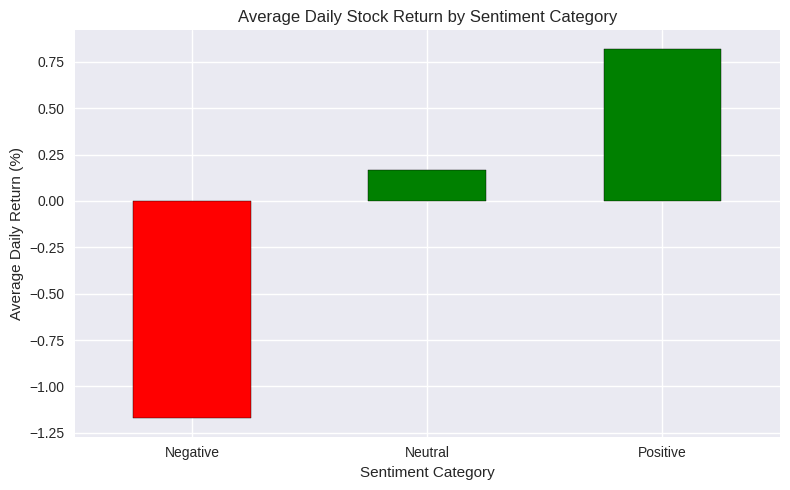

Bar chart saved!


In [10]:
# Cell 9: Average Return by Sentiment Category
merged_df['sentiment_category'] = merged_df['avg_sentiment'].apply(
    lambda x: 'Positive' if x >= 0.05 else ('Negative' if x <= -0.05 else 'Neutral')
)

avg_returns = merged_df.groupby('sentiment_category')['Daily_Return'].mean()
print("=== Average Daily Return by Sentiment Category ===")
print(avg_returns)

plt.figure(figsize=(8, 5))
colors = ['green' if x > 0 else 'red' for x in avg_returns.values]
avg_returns.plot(kind='bar', color=colors, edgecolor='black')
plt.title('Average Daily Stock Return by Sentiment Category')
plt.xlabel('Sentiment Category')
plt.ylabel('Average Daily Return (%)')
plt.xticks(rotation=0)
plt.tight_layout()
plt.savefig('notebooks/avg_return_by_sentiment.png', dpi=150)
plt.show()
print("Bar chart saved!")

In [11]:
# Cell 10: Save merged data
os.makedirs('data/processed', exist_ok=True)
merged_df.to_csv('data/processed/sentiment_returns_merged.csv', index=False)
print("Merged data saved!")
print(f"Final shape: {merged_df.shape}")

Merged data saved!
Final shape: (1566, 7)
